<a href="https://colab.research.google.com/github/springboardmentor468a/Projects/blob/ImageSegmentation-AryaaAgarwal/week5_output.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision albumentations pycocotools -q

import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models.segmentation as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.datasets import CocoDetection
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm import tqdm

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_root = "/content/drive/MyDrive/Colab Notebooks/VisionExtraction/val2017"
ann_file  = "/content/drive/MyDrive/Colab Notebooks/VisionExtraction/annotations/instances_val2017.json"
model_path = "/content/drive/MyDrive/Colab Notebooks/VisionExtraction/Projects/best_model11.pth"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
class CocoSegmentation(torch.utils.data.Dataset):
    def __init__(self, root, annFile, transforms=None):
        self.dataset = CocoDetection(root, annFile)
        self.transforms = transforms

    def __getitem__(self, idx):
        img, target = self.dataset[idx]
        img = np.array(img)

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for obj in target:
            rle = self.dataset.coco.annToMask(obj)
            mask = np.maximum(mask, rle)
        mask = mask.astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        return img, mask.long()

    def __len__(self):
        return len(self.dataset)

In [6]:
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

In [7]:
val_dataset = CocoSegmentation(data_root, ann_file, transforms=val_transform)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)


loading annotations into memory...
Done (t=2.93s)
creating index...
index created!


In [8]:
import torchvision.models.segmentation as models
import torch
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Define model exactly like training for main classifier ---
model = models.deeplabv3_resnet50(pretrained=False)

# Replace main classifier for 2 classes
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)

# --- Load checkpoint safely ---
# If your checkpoint has aux_classifier keys, we can ignore them since we don't need aux output
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict, strict=False)  # ignore unexpected keys

# Move model to device
model.to(device)
model.eval()

print("✅ Model loaded successfully for inference")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.2MB/s]


✅ Model loaded successfully for inference


In [9]:
def denormalize(img_tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return np.clip(img.permute(1,2,0).numpy(), 0, 1)


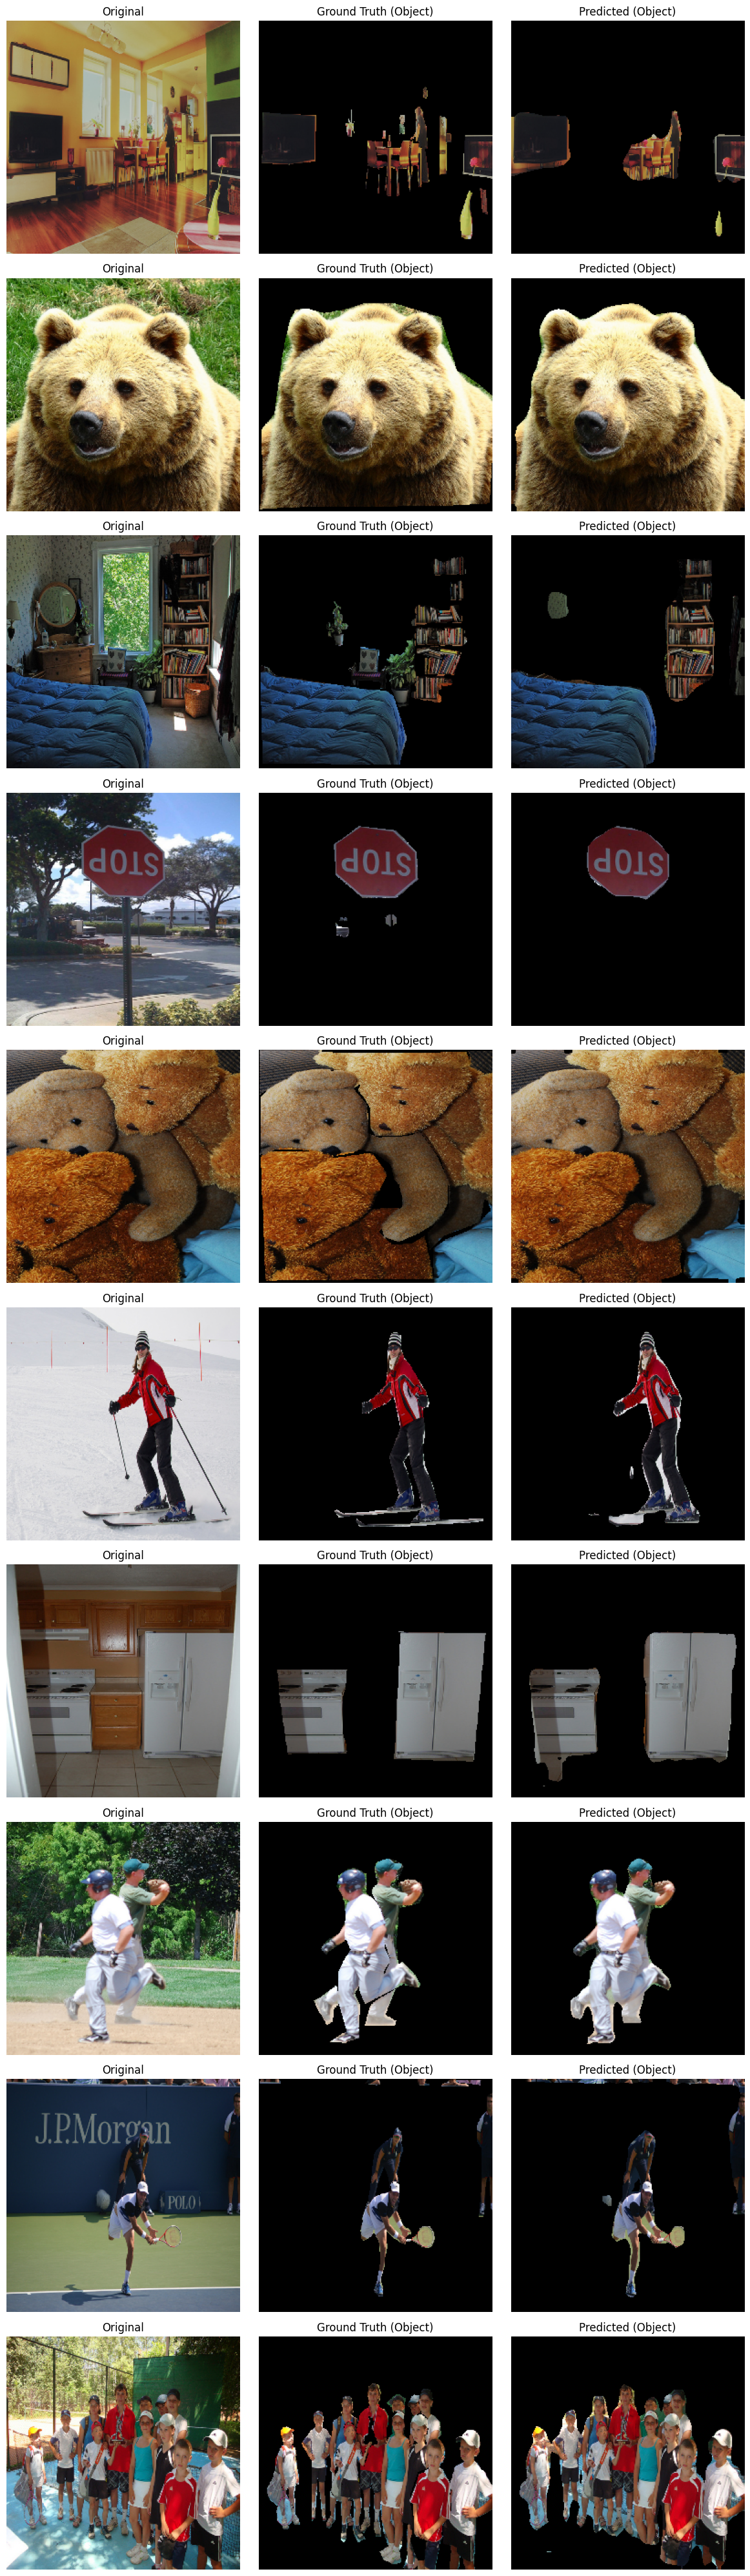

In [10]:
num_to_show = 10
images_list, masks_list = [], []
collected = 0
val_iter = iter(val_loader)

# Collect enough images
while collected < num_to_show:
    try:
        imgs, msks = next(val_iter)
    except StopIteration:
        break
    images_list.append(imgs)
    masks_list.append(msks)
    collected += imgs.size(0)

# Concatenate and move to device
images = torch.cat(images_list, dim=0).to(device)
masks = torch.cat(masks_list, dim=0).to(device)

# Run model
model.eval()
with torch.no_grad():
    outputs = model(images)['out']
preds = torch.argmax(outputs, dim=1)

num_samples = min(num_to_show, len(images))
plt.figure(figsize=(12, 4*num_samples))

# Function to denormalize
def denormalize(img_tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.permute(1,2,0).numpy()
    return np.clip(img, 0, 1)  # ensure [0,1] for matplotlib

for i in range(num_samples):
    pred_mask = (preds[i] == 1).cpu().numpy().astype(np.float32)  # 0/1 float
    gt_mask   = (masks[i] == 1).cpu().numpy().astype(np.float32)  # 0/1 float
    img_np = denormalize(images[i])

    # Original Image
    plt.subplot(num_samples, 3, i*3+1)
    plt.imshow(img_np)
    plt.axis('off')
    plt.title("Original")

    # Ground Truth: main object only, background black
    gt_display = img_np * gt_mask[:, :, None]  # mask the image
    plt.subplot(num_samples, 3, i*3+2)
    plt.imshow(gt_display)
    plt.axis('off')
    plt.title("Ground Truth (Object)")

    # Prediction: main object only, background black
    pred_display = img_np * pred_mask[:, :, None]  # mask the image
    plt.subplot(num_samples, 3, i*3+3)
    plt.imshow(pred_display)
    plt.axis('off')
    plt.title("Predicted (Object)")

plt.tight_layout()
plt.show()
